# Machine Learning 1 - Group Project 
## Group 4
Diego Gaitan <br>
Romain Gerlain <br>
Juan José Rincón <br>
Cecile Tambey<br>
Luka Tcheishvili<br>

This notebook is organized in the following sections:

* [Step 0 - Import packages and dataset](#0)
* [Step 1 - Exploratory Data Analysis (EDA)](#1)
    
    * [Step 1.1 - Identification of missing values and their possible meaning](#11) 
    * [Step 1.2 - Missing values handling](#12) 
    * [Step 1.3 - Outliers handling](#13) 
    * [Step 1.4 - Redundancy analysis](#14) 
* [Step 2 - Segmentation](#2)


<a id='0'></a>
## Import packages and dataset

In [4]:
import pandas as pd
import numpy as np
import os
import seaborn
import sklearn
from sklearn.cluster import KMeans

In [5]:
#os.chdir(r'C:\Users\LukaCheishvili\Documents\GitHub\IE-MBDS-ML-1-group-project')
#os.chdir('/Users/juanjose/Library/CloudStorage/GoogleDrive-jj.rincon@student.ie.edu/My Drive/term 2/ML 1/group assignment/IE-MBDS-ML-1-group-project')
os.chdir('/Users/ceciletambey/Desktop/ML/IE-MBDS-ML-1-group-project')

In [6]:
df = pd.read_excel("data/Houses for rent in Madrid.xlsx")
df.head()

,Id,District,Address,Number,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
0,1,Ciudad Lineal,Piso en Quintana,NaN,Quintana,1300,2.0,72,3.0,1.0,1.0,0,0,0,0
1,2,Ciudad Lineal,Piso en calle de Arturo Soria,NaN,Costillares,3000,5.0,260,2.0,1.0,1.0,0,0,0,0
2,3,Ciudad Lineal,Piso en calle de Vicente Muzas,4,Colina,1300,2.0,100,3.0,1.0,1.0,0,0,0,0
3,4,Ciudad Lineal,Piso en calle Badajoz,NaN,San Pascual,1600,3.0,120,4.0,1.0,1.0,0,0,0,0
4,5,Ciudad Lineal,Piso en calle de Nuestra Señora del Villar,9,Ventas,800,2.0,60,3.0,1.0,0.0,0,0,0,0


<a id='1'></a>
# Exploratory Data Analysis (EDA)

In the Address column you have the rent description with the type of real estate ('piso','chalet','estudio',etc.) and the address where it is located, we could split the column to get a type column separated from the address.

In [7]:
df = df.rename(columns={'Address':'Description'})
df[['type', 'Address']] = df['Description'].str.split(' en ', n=1, expand=True)
df

,Id,District,Description,Number,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,type,Address
0,1,Ciudad Lineal,Piso en Quintana,NaN,Quintana,1300,2.0,72,3.0,1.0,1.0,0,0,0,0,Piso,Quintana
1,2,Ciudad Lineal,Piso en calle de Arturo Soria,NaN,Costillares,3000,5.0,260,2.0,1.0,1.0,0,0,0,0,Piso,calle de Arturo Soria
2,3,Ciudad Lineal,Piso en calle de Vicente Muzas,4,Colina,1300,2.0,100,3.0,1.0,1.0,0,0,0,0,Piso,calle de Vicente Muzas
3,4,Ciudad Lineal,Piso en calle Badajoz,NaN,San Pascual,1600,3.0,120,4.0,1.0,1.0,0,0,0,0,Piso,calle Badajoz
4,5,Ciudad Lineal,Piso en calle de Nuestra Señora del Villar,9,Ventas,800,2.0,60,3.0,1.0,0.0,0,0,0,0,Piso,calle de Nuestra Señora del Villar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2084,2184,Vicálvaro,Piso en calle Villajoyosa,99,Los Rosales,1100,3.0,70,3.0,1.0,1.0,0,0,0,0,Piso,calle Villajoyosa
2085,2185,Vicálvaro,Piso en Los Ángeles,NaN,Los Ángeles,670,2.0,61,NaN,0.0,0.0,0,0,0,0,Piso,Los Ángeles
2086,2186,Vicálvaro,Piso en San Andrés,NaN,San Andrés,450,1.0,45,NaN,0.0,0.0,0,0,0,0,Piso,San Andrés
2087,2187,Vicálvaro,Piso en calle del Doctor MartÃ­n ArÃ©valo,35,San Andrés,750,2.0,92,0.0,1.0,1.0,0,0,0,0,Piso,calle del Doctor MartÃ­n ArÃ©valo


In [8]:
df[['type','Cottage','Duplex','Penthouse']].value_counts()

type                         Cottage  Duplex  Penthouse
Piso                         0        0       0            1675
Ático                        0        0       1             169
Estudio                      0        0       0              92
Dúplex                       0        1       0              64
Casa o chalet independiente  1        0       0              36
Chalet adosado               1        0       0              27
Chalet pareado               1        0       0              19
Chalet                       1        0       0               5
Caserón                      1        0       0               1
Chalet adosado               0        0       0               1
Name: count, dtype: int64

it seams that there is one real state that is categorized as being in a building (no Cottage) but its description is from a Chalet adosado. The inspection of that row shows that the categorization has done wrongly so we change the Cottage value to 1. 

In [9]:
df.loc[(df['type']=='Chalet adosado')&(df['Cottage']==0)]

,Id,District,Description,Number,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,type,Address
1805,1888,San Blás,Chalet adosado en Rejas,NaN,Rejas,1600,3.0,220,0.0,0.0,0.0,0,0,0,0,Chalet adosado,Rejas


In [10]:
df.loc[(df['type']=='Chalet adosado')&(df['Cottage']==0),'Cottage'] = 1

All no cottage real state are categorized bewteen Duplex and Penthouse, but it is also missing a possible category, Studio (all in one space). we create this category as a variable. 

In [11]:
df['Studio'] = np.where(df['type']=='Estudio',1,0)

In [12]:
df[['type','Cottage','Duplex','Penthouse','Studio']].value_counts()

type                         Cottage  Duplex  Penthouse  Studio
Piso                         0        0       0          0         1675
Ático                        0        0       1          0          169
Estudio                      0        0       0          1           92
Dúplex                       0        1       0          0           64
Casa o chalet independiente  1        0       0          0           36
Chalet adosado               1        0       0          0           28
Chalet pareado               1        0       0          0           19
Chalet                       1        0       0          0            5
Caserón                      1        0       0          0            1
Name: count, dtype: int64

From the cottage real state, there are someones that are 'adosado' which mean the cottage are semi detached, are not completely independent from another real state. Though, some of the real state types records are wrongly categorized, like 'Chalet pareado' and 'chalet adosado' should be a cottage semidetached, also a 'Chalet' should not be semidetached.  

In [13]:
df[['type','Cottage','Semidetached']].value_counts()

type                         Cottage  Semidetached
Piso                         0        0               1675
Ático                        0        0                169
Estudio                      0        0                 92
Dúplex                       0        0                 64
Casa o chalet independiente  1        0                 36
Chalet adosado               1        1                 27
Chalet pareado               1        0                 19
Chalet                       1        0                  4
Caserón                      1        0                  1
Chalet                       1        1                  1
Chalet adosado               1        0                  1
Name: count, dtype: int64

In [14]:
df.loc[(df['type']=='Chalet pareado')&(df['Cottage']==1),'Semidetached'] = 1

df.loc[(df['type']=='Chalet adosado')&(df['Cottage']==1),'Semidetached'] = 1

df.loc[(df['type']=='Chalet')&(df['Cottage']==1)&(df['Semidetached']==1),'Semidetached'] = 0


In [15]:
df[['type','Cottage','Semidetached']].value_counts()

type                         Cottage  Semidetached
Piso                         0        0               1675
Ático                        0        0                169
Estudio                      0        0                 92
Dúplex                       0        0                 64
Casa o chalet independiente  1        0                 36
Chalet adosado               1        1                 28
Chalet pareado               1        1                 19
Chalet                       1        0                  5
Caserón                      1        0                  1
Name: count, dtype: int64

<a id='11'></a>
### Identification of missing values and their possible meaning

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2089 entries, 0 to 2088
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2089 non-null   int64  
 1   District      2089 non-null   object 
 2   Description   2089 non-null   object 
 3   Number        747 non-null    object 
 4   Area          2085 non-null   object 
 5   Rent          2089 non-null   int64  
 6   Bedrooms      2000 non-null   float64
 7   Sq.Mt         2089 non-null   int64  
 8   Floor         1948 non-null   float64
 9   Outer         1927 non-null   float64
 10  Elevator      1956 non-null   float64
 11  Penthouse     2089 non-null   int64  
 12  Cottage       2089 non-null   int64  
 13  Duplex        2089 non-null   int64  
 14  Semidetached  2089 non-null   int64  
 15  type          2089 non-null   object 
 16  Address       2089 non-null   object 
 17  Studio        2089 non-null   int64  
dtypes: float64(4), int64(8), obj

In [17]:
pd.DataFrame({
    'Nan count': df.isna().sum(),
    'Nan %': df.isna().mean() * 100
})

,Nan count,Nan %
Id,0,0.000000
District,0,0.000000
Description,0,0.000000
Number,1342,64.241264
Area,4,0.191479
Rent,0,0.000000
Bedrooms,89,4.260412
Sq.Mt,0,0.000000
Floor,141,6.749641
Outer,162,7.754907


From the columns with Nan values, Number is the one that has the most, 1342 (64%). This column identifies the street number of the address, which is not required in our model. Additionally, since there is no point in trying to handle all those missing values, this column will be droped from the dataset

Lets inspect the Bedrooms missing values: <br> 
From the 89 rows that has missing values in Bedrooms, out of the 82 are of type 'Studio', only a few are 'Penthouse' (5) and 'Duplex' (2). <br> 
We could see that from the 92 records of type 'Studio' 82 of them are the ones that have Nan in Bedrooms, the other 10 records Bedrooms value is 0. so we could replace the Nan with 0, which makes sense with the business, a 'Estudio' is a real estate that does not have a bedroom per se, but has a all in one space. 

In [18]:
df.loc[df['Bedrooms'].isna(),['Cottage','Semidetached','Duplex','Penthouse','Studio']].value_counts()

Cottage  Semidetached  Duplex  Penthouse  Studio
0        0             0       0          1         82
                               1          0          5
                       1       0          0          2
Name: count, dtype: int64

In [19]:
pd.DataFrame({
    'total count': [len(df.loc[(df['type'].isin(['Estudio']))])],
    'Nan count': [len(df.loc[(df['type'].isin(['Estudio']))&(df['Bedrooms'].isna())])],
    'Nan %': [( len(df.loc[(df['type'].isin(['Estudio']))&(df['Bedrooms'].isna())]) ) / ( len(df.loc[(df['type'].isin(['Estudio']))]) ) * 100]
})

,total count,Nan count,Nan %
0,92,82,89.130435


In [20]:
df.loc[(df['type'].isin(['Estudio']))&(~df['Bedrooms'].isna()),'Bedrooms'].unique()

array([0.])

Floor: The floor has 141 Nan values, out of which 84 (60%) are Cottage, which are not located in any particular floor number, so they could be categorized to have floor 0 (basement). 

Elevator: There are 133 records that have Nan values in. 85 are from a cottage, which usually dont have elevator. we could categorized those Nan as elevator = 0.

In [21]:
df.loc[df['Floor'].isna(),['Cottage']].value_counts()

Cottage
1          84
0          57
Name: count, dtype: int64

In [22]:
df.loc[df['Elevator'].isna(),['Cottage']].value_counts()

Cottage
1          85
0          48
Name: count, dtype: int64

The Outer column identifies the real state that have sight (and enter) to the outside of the building, while the ones that are Outer==0, have sight (and enter) within the inside of the building. The data, and also by definition, there are no cottages that are identified as Outer==1. So in this sense, the records that has Nan values in Outer and are cottages (85/162) could be re stated to have a valuo of 0 in Outer column. There is no clear rule or definition for the other real states.

In [23]:
df.loc[(df['Outer']==1),['Cottage','Semidetached','Duplex','Penthouse','Studio']].value_counts()

Cottage  Semidetached  Duplex  Penthouse  Studio
0        0             0       0          0         1394
                               1          0          157
                               0          1           62
                       1       0          0           58
Name: count, dtype: int64

In [24]:
df.loc[df['Outer'].isna(),['Cottage','Semidetached']].value_counts()

Cottage  Semidetached
0        0               77
1        1               44
         0               41
Name: count, dtype: int64

In [25]:
df.loc[(df['Outer']==0),['Cottage','Semidetached','Duplex','Penthouse','Studio']].value_counts()

Cottage  Semidetached  Duplex  Penthouse  Studio
0        0             0       0          0         211
                                          1          28
                               1          0           7
                       1       0          0           6
1        1             0       0          0           3
         0             0       0          0           1
Name: count, dtype: int64

<a id='12'></a>
### Missing values handling

General missing values handling: drop Number column as it is non informative. drop the only 4 records that has missing values in Area column (neighborhood identifier).

In [26]:
df = df.drop(columns=['Number'])
df = df.dropna(subset=["Area"])

Replace missing values for Bendrooms, Floor, Elevator, Outer with the rules discussed above

In [27]:
df.loc[(df['Studio']==1)&(df['Bedrooms'].isna()),'Bedrooms'] = 0.0
df.loc[(df['Cottage']==1)&(df['Floor'].isna()),'Floor'] = 0
df.loc[(df['Cottage']==1)&(df['Elevator'].isna()),'Elevator'] = 0
df.loc[(df['Cottage']==1)&(df['Outer'].isna()),'Outer'] = 0


Verifiy the context of the left Nan values in Bedrooms

In [28]:
df.loc[df['Bedrooms'].isna(),['Cottage','Semidetached','Studio','Duplex','Penthouse']].value_counts()

Cottage  Semidetached  Studio  Duplex  Penthouse
0        0             0       0       1            5
                               1       0            2
Name: count, dtype: int64

Drop the 7 left records with Nan in Bedrooms.

In [29]:
df = df.dropna(subset=["Bedrooms"])

Verifiy the context of the left Nan values in Floor

In [30]:
df.loc[df['Floor'].isna(),['Cottage','Semidetached','Duplex','Penthouse','Studio']].value_counts()

Cottage  Semidetached  Duplex  Penthouse  Studio
0        0             0       0          0         53
                                          1          4
Name: count, dtype: int64

In [31]:
df.loc[df['Floor'].isna(),['District','Area','Rent','Bedrooms','Sq.Mt','Floor','Outer','Elevator']].head()

,District,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator
61,Ciudad Lineal,Concepción,1235,3.0,122,NaN,NaN,NaN
62,Ciudad Lineal,Concepción,1235,3.0,122,NaN,NaN,NaN
82,Ciudad Lineal,Concepción,845,1.0,77,NaN,NaN,NaN
152,Fuencarral,Fuentelarreina,2400,4.0,219,NaN,NaN,NaN
198,Fuencarral,Montecarmelo,1350,3.0,116,NaN,NaN,1.0


Drop the 57 left records with Nan in Floor (57/2078, 2.8%), there is no way to know how to input these values without any major assumption, and indeed most of these records has also Nan values in Elavator and Outer

In [32]:
df = df.dropna(subset=["Floor"])

Verifiy the context of the left Nan values in Elevator

In [33]:
df.loc[df['Elevator'].isna(),['Cottage','Semidetached','Duplex','Penthouse','Studio']].value_counts()

Cottage  Semidetached  Duplex  Penthouse  Studio
0        0             0       0          0         20
                               1          0          1
Name: count, dtype: int64

In [34]:
df.loc[df['Elevator'].isna(),['District','Area','Rent','Bedrooms','Sq.Mt','Floor','Outer','Elevator']].head()

,District,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator
219,Hortaleza,Conde Orgaz-Piovera,3300,5.0,234,2.0,1.0,NaN
299,Hortaleza,Sanchinarro,900,1.0,64,5.0,NaN,NaN
352,Latina,Los Cármenes,700,2.0,60,3.0,NaN,NaN
508,Moncloa,Aravaca,3500,5.0,250,1.0,NaN,NaN
547,Puente Vallecas,Numancia,650,2.0,55,1.0,NaN,NaN


Drop the 21 left records with Nan in Elavator (21/2021, 1%), there is no way to know how to input these values without any major assumption, and indeed most of these records has also Nan values in Outer

In [35]:
df = df.dropna(subset=["Elevator"])

Verifiy the context of the left Nan values in Outer

In [36]:
df.loc[df['Outer'].isna(),['Cottage','Semidetached','Duplex','Penthouse','Studio']].value_counts()

Cottage  Semidetached  Duplex  Penthouse  Studio
0        0             0       0          0         16
                               1          0          4
Name: count, dtype: int64

In [37]:
df.loc[df['Outer'].isna(),['District','Area','Rent','Bedrooms','Sq.Mt','Floor','Outer','Elevator']].head()

,District,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator
140,Fuencarral,Pilar,900,3.0,80,8.0,NaN,1.0
290,Hortaleza,Valdebebas - Valdefuentes,1600,4.0,94,4.0,NaN,1.0
358,Latina,Águilas,780,3.0,82,0.0,NaN,1.0
553,Puente Vallecas,Palomeras Bajas,1175,3.0,50,2.0,NaN,0.0
668,Salamanca,Recoletos,1300,1.0,69,6.0,NaN,1.0


Drop the 20 left records with Nan in Outer (20/2000, 1%), there is no way to know how to input these values without any major assumption, they are non informative.

In [38]:
df = df.dropna(subset=["Outer"])

In [39]:
pd.DataFrame({
    'Nan count': df.isna().sum(),
    'Nan %': df.isna().mean() * 100
})

,Nan count,Nan %
Id,0,0.0
District,0,0.0
Description,0,0.0
Area,0,0.0
Rent,0,0.0
Bedrooms,0,0.0
Sq.Mt,0,0.0
Floor,0,0.0
Outer,0,0.0
Elevator,0,0.0


<a id='13'></a>
### Outliers handling

Lets inspect the possible outliers for cottage real state. its importante to inspect cottage deifferent that builing flats due to the structure difference in floors, sq meters, rooms, where usually cottages have higher values, of bedrooms, and sq meters, but floor should be 0.

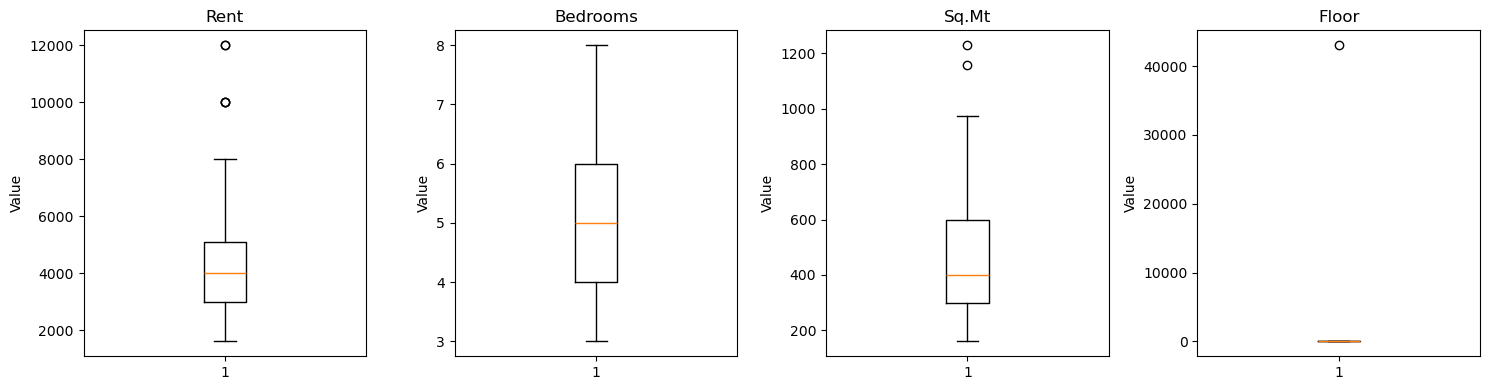

In [40]:
import matplotlib.pyplot as plt

# Create a figure with subplots for each numerical column 
numerical_cols = ['Rent','Bedrooms', 'Sq.Mt', 'Floor']
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(15, 4))

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df.loc[df['Cottage']==1,col])
    axes[idx].set_title(col)
    axes[idx].set_ylabel('Value')

plt.tight_layout()
plt.show()

inspect the cottage with a floor greater than 0. it seams like an data entry error in that column (43039, maybe the zip code). it just could be clamped to 0. 

In [41]:
df.loc[(df['Floor']>=1)&(df['Cottage']==1)]

,Id,District,Description,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,type,Address,Studio
1418,1485,Chamartín,Chalet adosado en El Viso,en El Viso,7500,5.0,310,43039.0,0.0,0.0,0,1,0,1,Chalet adosado,El Viso,0


In [42]:
df.loc[(df['Floor']>=1)&(df['Cottage']==1),'Floor'] = 0

Inspect the cottage with a sq meters greater than 1000, percentile 90%. It seams like those showed not the build area, but the whole land area size, which is not what we are using to measure real state, so we could drop these ones. 

In [43]:
df.loc[(df['Sq.Mt']>=1000)&(df['Cottage']==1)]

,Id,District,Description,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,type,Address,Studio
408,430,Moncloa,Casa o chalet independiente en Valdemarín,Valdemarín,8000,6.0,1160,0.0,0.0,0.0,0,1,0,0,Casa o chalet independiente,Valdemarín,0
410,432,Moncloa,Casa o chalet independiente en Ciudad Universi...,Ciudad Universitaria,12000,7.0,1230,0.0,0.0,0.0,0,1,0,0,Casa o chalet independiente,Ciudad Universitaria,0


In [44]:
df = df.loc[~((df['Sq.Mt']>=1000)&(df['Cottage']==1))]

Lets inspect the possible outliers for non cottage real state. <br> 
Floor usual values are between 0-10 and have some values above the percentile 90% until 30 floor, which is possible, to have real state in building up to 30 floors in madrid. <br>
Sqt meters usual values are between 0-250 and have some values above the percentile 90% until 600 sqt meters. It seams intuitive to have flats between 0-250 meters, and some greater than 250 until 600 that could be the 'old big' flats. though, there is a flat with more than 1200 sq meters which doesnt makes much sense, we should inspect this one, to drop it or change its value.  

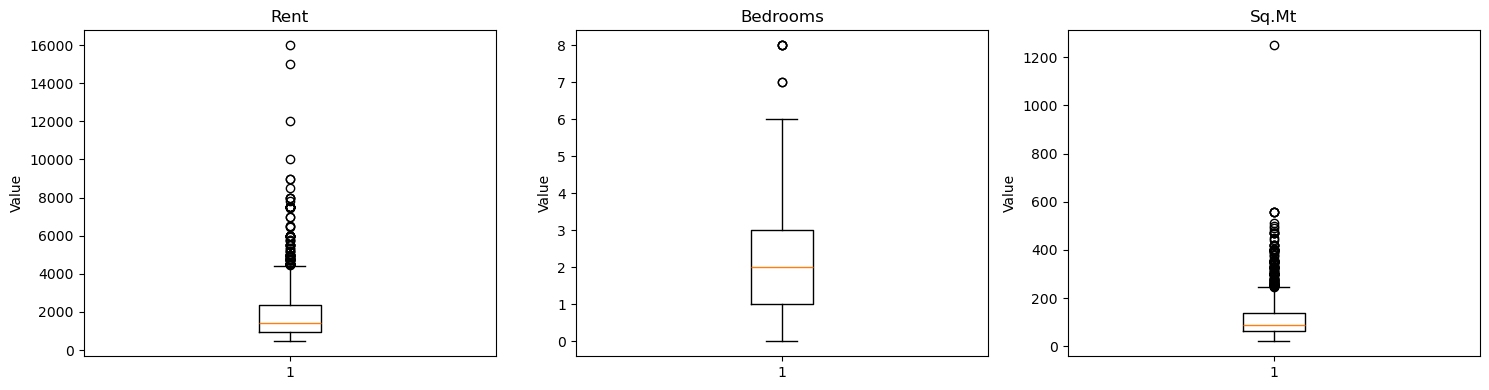

In [45]:
import matplotlib.pyplot as plt

# Create a figure with subplots for each numerical column 
numerical_cols = ['Rent','Bedrooms', 'Sq.Mt']
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(15, 4))

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df.loc[df['Cottage']==0,col])
    axes[idx].set_title(col)
    axes[idx].set_ylabel('Value')

plt.tight_layout()
plt.show()

In [46]:
df.loc[(df['Sq.Mt']>=1000)&(df['Cottage']==0)]

,Id,District,Description,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,type,Address,Studio
1757,1836,Chamberí,Piso en Almagro,Almagro,15000,8.0,1250,4.0,1.0,1.0,0,0,0,0,Piso,Almagro,0


<a id='14'></a>

## Descriptive statistics & Redundancy analyisis

In [47]:
df[['Id', 'District', 'Description', 'Area', 'Rent', 'Bedrooms', 'Sq.Mt','Floor', 'Outer', 'Elevator', 'Penthouse', 'Cottage', 'Duplex','Semidetached', 'type', 'Address', 'Studio']].describe()

,Id,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,Studio
count,1978.000000,1978.000000,1978.000000,1978.000000,1978.000000,1978.000000,1978.000000,1978.000000,1978.000000,1978.000000,1978.000000,1978.000000
mean,1092.459050,1957.251769,2.389788,129.970677,3.423660,0.836704,0.854904,0.080384,0.043984,0.031345,0.023761,0.044489
std,629.932547,1489.273823,1.371447,112.405730,3.011903,0.369729,0.352287,0.271956,0.205111,0.174292,0.152343,0.206232
min,1.000000,450.000000,0.000000,20.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,553.250000,980.000000,1.000000,65.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1086.500000,1450.000000,2.000000,92.500000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1634.750000,2500.000000,3.000000,150.000000,5.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2188.000000,16000.000000,8.000000,1250.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [48]:
numeric_cols = ['Rent','Bedrooms', 'Sq.Mt', 'Floor', 'Outer', 'Elevator', 'Penthouse', 'Cottage', 'Duplex','Semidetached', 'Studio']


<Axes: >

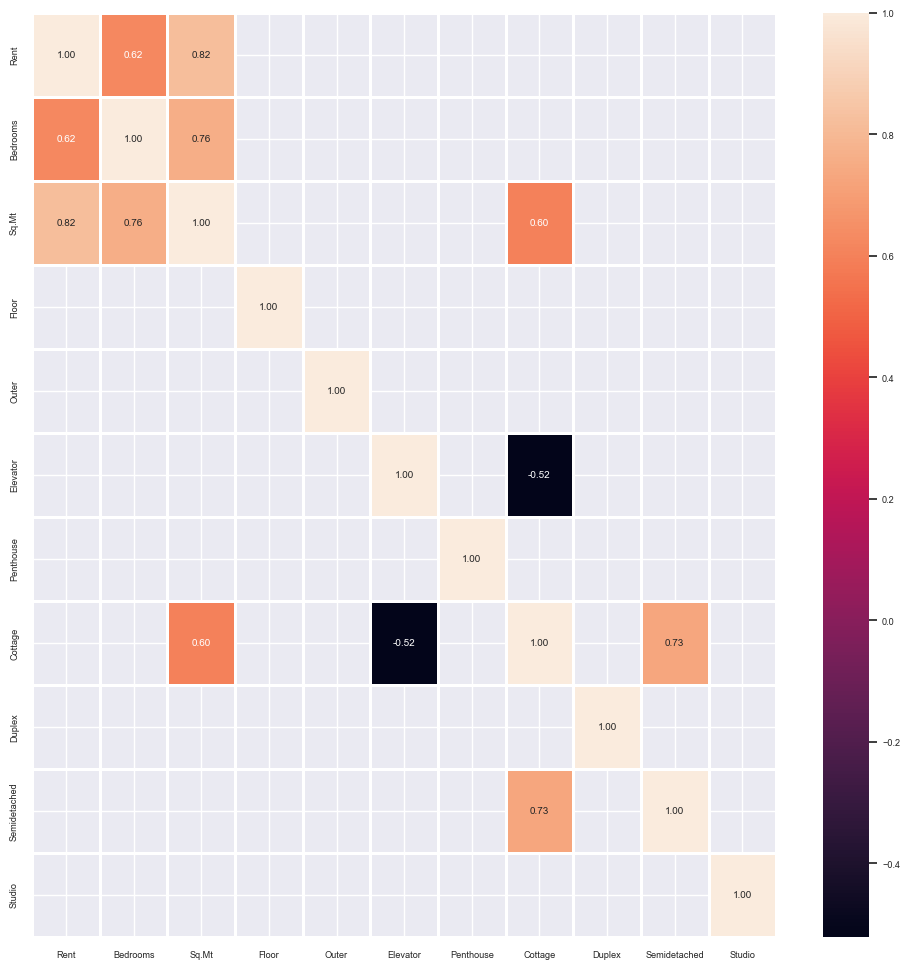

In [49]:
import seaborn as sns

X = df[numeric_cols]
corr_matrix = X.corr()
high_corr = corr_matrix[abs(corr_matrix) > 0.5]
sns.set(font_scale=0.6)

# Show now only pairs with an absolute correlation value above 0.4
fig, ax = plt.subplots(figsize=(12,12))         
sns.heatmap(high_corr, annot=True, fmt=".2f", linewidths=1, ax=ax)

### One Hot Encoding

In [50]:
df['District'].value_counts()

District
Salamanca            304
Centro               262
Chamartín            205
Chamberí             188
Moncloa              154
Tetuán               141
Hortaleza            112
Fuencarral           108
Ciudad Lineal         97
Retiro                79
San Blás              56
Arganzuela            55
Carabanchel           45
Puente Vallecas       37
Villa de Vallecas     29
Latina                27
Usera                 22
Vicálvaro             22
Barajas               21
Moratalaz             14
Name: count, dtype: int64

In [51]:
from sklearn.preprocessing import OneHotEncoder

OneHotEncoder()
encoder = OneHotEncoder(sparse_output=False, drop='first')

encoded = encoder.fit_transform(df[['District']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['District']),
    index=df.index
)

df = pd.concat([df, encoded_df],axis=1)

df

,Id,District,Description,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,...,District_Moncloa,District_Moratalaz,District_Puente Vallecas,District_Retiro,District_Salamanca,District_San Blás,District_Tetuán,District_Usera,District_Vicálvaro,District_Villa de Vallecas
0,1,Ciudad Lineal,Piso en Quintana,Quintana,1300,2.0,72,3.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Ciudad Lineal,Piso en calle de Arturo Soria,Costillares,3000,5.0,260,2.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,Ciudad Lineal,Piso en calle de Vicente Muzas,Colina,1300,2.0,100,3.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Ciudad Lineal,Piso en calle Badajoz,San Pascual,1600,3.0,120,4.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Ciudad Lineal,Piso en calle de Nuestra Señora del Villar,Ventas,800,2.0,60,3.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,2182,Vicálvaro,Piso en Butarque,Butarque,850,3.0,97,2.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2083,2183,Vicálvaro,Piso en avenida de la verbena de la paloma,Los Ángeles,650,3.0,65,5.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2084,2184,Vicálvaro,Piso en calle Villajoyosa,Los Rosales,1100,3.0,70,3.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2087,2187,Vicálvaro,Piso en calle del Doctor MartÃ­n ArÃ©valo,San Andrés,750,2.0,92,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


<a id='2'></a>
# Segementation

Scaling variables

In [52]:
from sklearn.preprocessing import StandardScaler

# Define structural features correctly
features = ['Sq.Mt', 'Floor', 'Studio', 'Bedrooms', 'Cottage', 'Elevator', 'Semidetached', 
            'District_Barajas', 'District_Carabanchel', 'District_Centro', 'District_Chamartín',
            'District_Chamberí', 'District_Ciudad Lineal', 'District_Fuencarral',
            'District_Hortaleza', 'District_Latina', 'District_Moncloa',
            'District_Moratalaz', 'District_Puente Vallecas', 'District_Retiro',
            'District_Salamanca', 'District_San Blás', 'District_Tetuán',
            'District_Usera', 'District_Vicálvaro', 'District_Villa de Vallecas']

# Select features
X = df[features].copy()

# Standardize features (required for distance-based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Segmentation

In [53]:
import numpy as np
from collections import Counter
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

In [54]:
def cluster_size_stats(labels):
    n = len(labels)
    noise_ratio = np.mean(labels == -1)

    # counts excluding noise
    counts = Counter(labels)
    counts.pop(-1, None)

    if len(counts) == 0:
        return noise_ratio, 0.0, 0.0, {}

    sizes = np.array(list(counts.values()), dtype=float)
    min_cluster_pct = sizes.min() / n
    max_cluster_pct = sizes.max() / n

    return float(noise_ratio), float(min_cluster_pct), float(max_cluster_pct), dict(counts)

In [55]:
def DBSCAN_elbow_method(X, min_pct_obs_cluster=0.05, max_noise=0.33, require_two_clusters=True, plot=True):
    min_pts = round(len(X)*min_pct_obs_cluster)
    print('min_samples',min_pts)
    neighbors = NearestNeighbors(n_neighbors=min_pts)
    distances, _ = neighbors.fit(X).kneighbors(X)

    sorted_distances = np.sort(distances[:, min_pts - 1], axis=0)
    indices = np.arange(len(sorted_distances))

    p1 = np.array([indices[0], sorted_distances[0]])
    p2 = np.array([indices[-1], sorted_distances[-1]])

    curve = np.vstack((indices, sorted_distances)).T
    distances_toline = np.abs(np.cross(p2 - p1, p1 - curve)) / np.linalg.norm(p2 - p1)

    # Rank epsilon candidates by elbow "strength"
    order = np.argsort(distances_toline)[::-1]

    chosen = None
    for idx in order:
        eps = float(sorted_distances[idx])

        # DBSCAN requires eps > 0
        if eps <= 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_pts).fit_predict(X)
        noise_ratio, min_cluster_pct, max_cluster_pct, _ = cluster_size_stats(labels)
        
        if noise_ratio > max_noise:
            continue

        mask = labels != -1
        n_clusters = len(set(labels[mask]))

        if require_two_clusters and n_clusters < 2:
            continue

        # silhouette for DBSCAN: exclude noise, needs >=2 clusters
        sil = None
        if n_clusters >= 2:
            sil = silhouette_score(X[mask], labels[mask])

        chosen = {
            'min_pts':min_pts,
            "optimal_eps": eps,
            "sil": None if sil is None else float(sil),
            "n_clusters": int(n_clusters),
            "noise_ratio": float(noise_ratio),
            "sorted_distances": sorted_distances,
        }
        print(f"Epsilon suggested: {chosen['optimal_eps']:.3f}")
        print(f"Clusters found: {chosen['n_clusters']}")
        print(f"noise %: {round(noise_ratio*100,2)}")
        print(f"min clusters %: {round(min_cluster_pct*100,2)}")
        print(f"max clusters %: {round(max_cluster_pct*100,2)}")
        print("Silhouette Score:", chosen['sil'])
        break

    if chosen is None:
        raise ValueError(
            f"No epsilon found that satisfies noise_ratio <= {max_noise:.0%}"
            + (" and >=2 clusters." if require_two_clusters else ".")
        )

    if plot:
        plt.figure(figsize=(10, 6))
        plt.plot(sorted_distances)
        plt.axhline(y=chosen["optimal_eps"], color="r", linestyle="--",
                    label=f'Chosen ε={chosen["optimal_eps"]:.3f} (noise={chosen["noise_ratio"]:.0%})')
        plt.ylabel(f"Distance to {min_pts} neighbours (Epsilon)")
        plt.xlabel("Observations ordered by distance")
        plt.title(f"Distance chart with KNN (K={min_pts}) for DBSCAN")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend()
        plt.show()

    return chosen

In [56]:

def DBSCAN_best_silhouette(X, eps_values, min_pct_obs_cluster=0.05, max_noise=0.33, plot=False):
    
    min_samples = round(len(X)*min_pct_obs_cluster)
    print('min_samples',min_samples)
    best_eps = None
    best_sil = -np.inf

    eps_hist = []
    sil_hist = []

    for eps in eps_values:
        
        # Skip invalid eps
        if eps <= 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)

        noise_ratio, min_cluster_pct, max_cluster_pct, _ = cluster_size_stats(labels)
        
        if noise_ratio > max_noise:
            continue

        mask = labels != -1
        n_clusters = len(set(labels[mask]))

        # Silhouette requires at least 2 clusters
        if n_clusters < 2:
            continue

        sil = silhouette_score(X[mask], labels[mask])

        eps_hist.append(float(eps))
        sil_hist.append(float(sil))

        if sil > best_sil:
            best_labels = labels 
            best_n_clusters = len(set(labels[mask]))
            best_sil = sil
            best_eps = eps
            best_noise_ratio, best_min_cluster_pct, best_max_cluster_pct, _ = cluster_size_stats(labels)
            
    print("Best epsilon:", best_eps)
    print(f"Clusters found: {best_n_clusters}")
    print(f"noise %: {round(best_noise_ratio*100,2)}")
    print(f"min clusters %: {round(best_min_cluster_pct*100,2)}")
    print(f"max clusters %: {round(best_max_cluster_pct*100,2)}")
    print("Silhouette Score:", best_sil)
    
    if best_eps is None:
        raise ValueError("No epsilon satisfied the noise and clustering constraints.")

    if plot:
        plt.figure(figsize=(10, 6))
        plt.plot(eps_hist, sil_hist)
        plt.axvline(best_eps, linestyle="--", label=f"Best ε = {best_eps:.4f}")
        plt.xlabel("Epsilon")
        plt.ylabel("Silhouette score")
        plt.title(f"DBSCAN: Silhouette vs Epsilon (noise ≤ {max_noise:.0%})")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend()
        plt.show()

    return {'best_eps':best_eps, 'best_sil':best_sil, 'min_pts':min_samples}

min_samples 99


/var/folders/qh/n5tzysc514l3jnqbfhpkv8wm0000gn/T/ipykernel_3840/4259889639.py:14: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances_toline = np.abs(np.cross(p2 - p1, p1 - curve)) / np.linalg.norm(p2 - p1)


Epsilon suggested: 4.393
Clusters found: 2
noise %: 30.59
min clusters %: 5.06
max clusters %: 64.36
Silhouette Score: 0.24515914011193127


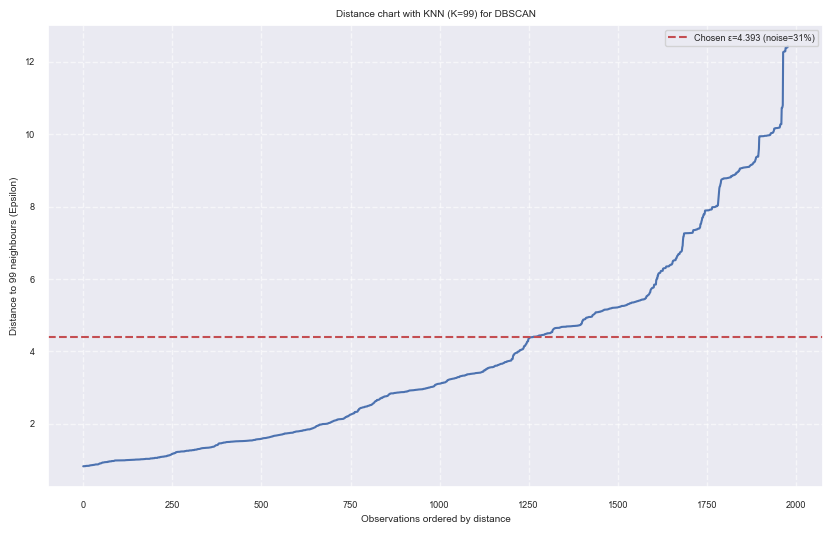

---- labels distribution ----


0 
 1    1273
-1     605
 0     100
Name: count, dtype: int64

In [57]:
elbow_method_results = DBSCAN_elbow_method(X = X_scaled)
print('---- labels distribution ----')
labels = DBSCAN(eps=elbow_method_results['optimal_eps'], min_samples=elbow_method_results['min_pts']).fit_predict(X_scaled)
pd.DataFrame(labels).value_counts()

In [58]:
best_sil_results = DBSCAN_best_silhouette(X = X_scaled, eps_values = elbow_method_results['sorted_distances'])
print('---- labels distribution ----')
labels = DBSCAN(eps=best_sil_results['best_eps'], min_samples=best_sil_results['min_pts']).fit_predict(X_scaled)
pd.DataFrame(labels).value_counts()

min_samples 99
Best epsilon: 4.331427866929333
Clusters found: 2
noise %: 32.96
min clusters %: 5.06
max clusters %: 61.98
Silhouette Score: 0.2566614344283236
---- labels distribution ----


0 
 1    1226
-1     652
 0     100
Name: count, dtype: int64

it seams that the given the min samples 5% threshold is too restrictive and just creates 2 clusters, we will try to relax it reducing it to 4.5%

our educated guess 

In [59]:

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.99, min_samples=80)

labels = DBSCAN(eps=elbow_method_results['optimal_eps'], min_samples=elbow_method_results['min_pts']).fit_predict(X_scaled)

pd.DataFrame(labels).value_counts()

0 
 1    1273
-1     605
 0     100
Name: count, dtype: int64

min_samples 89


/var/folders/qh/n5tzysc514l3jnqbfhpkv8wm0000gn/T/ipykernel_3840/4259889639.py:14: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances_toline = np.abs(np.cross(p2 - p1, p1 - curve)) / np.linalg.norm(p2 - p1)


Epsilon suggested: 3.518
Clusters found: 5
noise %: 30.03
min clusters %: 4.55
max clusters %: 47.78
Silhouette Score: 0.3618359076726124


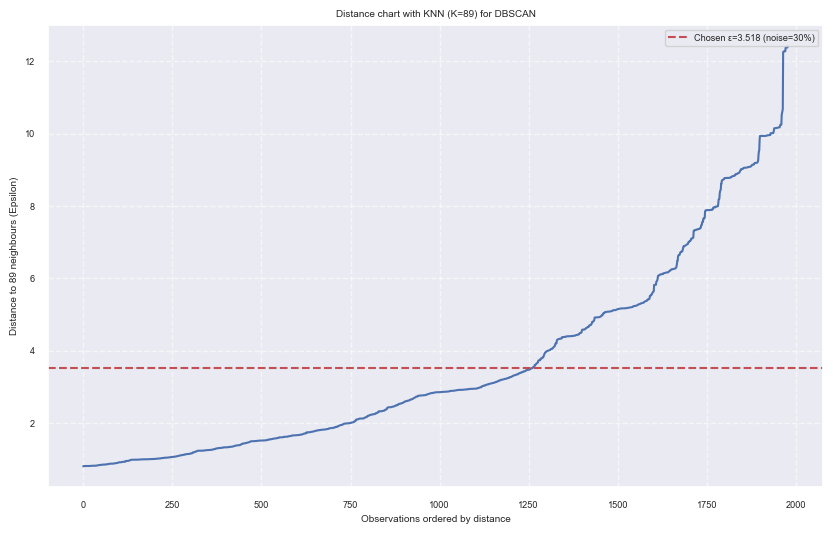

---- labels distribution ----


0 
 3    945
-1    594
 4    135
 2    114
 1    100
 0     90
Name: count, dtype: int64

In [60]:
elbow_method_results = DBSCAN_elbow_method(X = X_scaled, min_pct_obs_cluster = 0.045)
print('---- labels distribution ----')
labels = DBSCAN(eps=elbow_method_results['optimal_eps'], min_samples=elbow_method_results['min_pts']).fit_predict(X_scaled)
pd.DataFrame(labels).value_counts()

In [61]:
best_sil_results = DBSCAN_best_silhouette(X = X_scaled, eps_values = elbow_method_results['sorted_distances'], min_pct_obs_cluster=0.045)
print('---- labels distribution ----')
labels = DBSCAN(eps=best_sil_results['best_eps'], min_samples=best_sil_results['min_pts']).fit_predict(X_scaled)
pd.DataFrame(labels).value_counts()

min_samples 89
Best epsilon: 3.239084187828869
Clusters found: 7
noise %: 30.28
min clusters %: 4.5
max clusters %: 29.47
Silhouette Score: 0.4842959825724708
---- labels distribution ----


0 
-1    599
 3    583
 4    193
 5    169
 6    134
 2    111
 1    100
 0     89
Name: count, dtype: int64

with a min sample of the 4.5% we have 5 clusters (max cluster has 48% of the data) with the elbow method, and 7 clusters (max cluster has 30% of the data) with the best silhouette. the next part would be to check the interpretation of those clusters

In [62]:
labels = DBSCAN(eps=elbow_method_results['optimal_eps'], min_samples=elbow_method_results['min_pts']).fit_predict(X_scaled)
df['elbow_clusters'] = labels
labels = DBSCAN(eps=best_sil_results['best_eps'], min_samples=best_sil_results['min_pts']).fit_predict(X_scaled)
df['sil_clusters'] = labels
labels = DBSCAN(eps=2.99, min_samples=80).fit_predict(X_scaled)
df['guess_clusters'] = labels

In [63]:
district_counts = pd.crosstab(df['elbow_clusters'], df['District'])
district_counts

District,Arganzuela,Barajas,Carabanchel,Centro,Chamartín,Chamberí,Ciudad Lineal,Fuencarral,Hortaleza,Latina,Moncloa,Moratalaz,Puente Vallecas,Retiro,Salamanca,San Blás,Tetuán,Usera,Vicálvaro,Villa de Vallecas
elbow_clusters,,,,,,,,,,,,,,,,,,,,
-1,1,21,45,27,12,19,7,8,112,27,40,14,37,79,10,56,6,22,22,29
0,0,0,0,0,0,0,90,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,100,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,114,0,0,0,0,0,0,0,0,0
3,54,0,0,235,193,169,0,0,0,0,0,0,0,0,294,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,135,0,0,0


In [64]:
district_counts = pd.crosstab(df['sil_clusters'], df['District'])
district_counts

District,Arganzuela,Barajas,Carabanchel,Centro,Chamartín,Chamberí,Ciudad Lineal,Fuencarral,Hortaleza,Latina,Moncloa,Moratalaz,Puente Vallecas,Retiro,Salamanca,San Blás,Tetuán,Usera,Vicálvaro,Villa de Vallecas
sil_clusters,,,,,,,,,,,,,,,,,,,,
-1,1,21,45,27,12,19,8,8,112,27,43,14,37,79,10,56,7,22,22,29
0,0,0,0,0,0,0,89,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,100,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,111,0,0,0,0,0,0,0,0,0
3,54,0,0,235,0,0,0,0,0,0,0,0,0,0,294,0,0,0,0,0
4,0,0,0,0,193,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,169,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,134,0,0,0


In [65]:
district_counts = pd.crosstab(df['guess_clusters'], df['District'])
district_counts

District,Arganzuela,Barajas,Carabanchel,Centro,Chamartín,Chamberí,Ciudad Lineal,Fuencarral,Hortaleza,Latina,Moncloa,Moratalaz,Puente Vallecas,Retiro,Salamanca,San Blás,Tetuán,Usera,Vicálvaro,Villa de Vallecas
guess_clusters,,,,,,,,,,,,,,,,,,,,
-1,1,21,45,27,13,19,7,8,112,27,44,14,37,79,10,56,7,22,22,29
0,0,0,0,0,0,0,90,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,100,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,110,0,0,0,0,0,0,0,0,0
3,54,0,0,235,0,0,0,0,0,0,0,0,0,0,294,0,0,0,0,0
4,0,0,0,0,192,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,169,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,134,0,0,0


In [66]:

numeric_vars = [
    'Rent', 'Bedrooms', 'Sq.Mt', 'Floor','Cottage',
    'Penthouse', 'Elevator', 'Duplex'
]

In [67]:
numeric_summary = (df.groupby('elbow_clusters')[numeric_vars]
    .agg(['min', 'max', 'mean','std'])
)
numeric_summary.T

elbow_clusters            -1            0            1            2  \
Rent      min     450.000000   680.000000   650.000000   660.000000   
          max   15000.000000  3500.000000  4500.000000  6000.000000   
          mean   1722.823232  1569.222222  1422.850000  2067.228070   
          std    1720.557353   790.453188   563.602811   998.926371   
Bedrooms  min       0.000000     1.000000     1.000000     1.000000   
          max       8.000000     5.000000     6.000000     6.000000   
          mean      2.402357     2.577778     2.740000     2.842105   
          std       1.667483     1.199042     1.133690     1.320894   
Sq.Mt     min      25.000000    45.000000    55.000000    47.000000   
          max    1250.000000   405.000000   490.000000   400.000000   
          mean    142.678451   126.566667   119.910000   140.842105   
          std     159.647766    82.606424    61.341089    84.422827   
Floor     min      -0.500000     0.000000     0.000000     0.000000   
          max      29.000000    13.000000    13.000000    17.000000   
          mean      2.786195     3.255556     4.210000     3.771930   
          std       3.436327     2.559675     2.962032     4.138712   
Cottage   min       0.000000     0.000000     0.000000     0.000000   
          max       1.000000     0.000000     0.000000     0.000000   
          mean      0.146465     0.000000     0.000000     0.000000   
          std       0.353869     0.000000     0.000000     0.000000   
Penthouse min       0.000000     0.000000     0.000000     0.000000   
          max       1.000000     1.000000     1.000000     1.000000   
          mean      0.048822     0.077778     0.100000     0.096491   
          std       0.215676     0.269322     0.301511     0.296567   
Elevator  min       0.000000     0.000000     0.000000     0.000000   
          max       1.000000     1.000000     1.000000     1.000000   
          mean      0.702020     0.911111     0.980000     0.921053   
          std       0.457756     0.286178     0.140705     0.270847   
Duplex    min       0.000000     0.000000     0.000000     0.000000   
          max       1.000000     1.000000     1.000000     1.000000   
          mean      0.018519     0.177778     0.010000     0.052632   
          std       0.134930     0.384467     0.100000     0.224283   

elbow_clusters             3             4  
Rent      min     500.000000    630.000000  
          max   16000.000000  10000.000000  
          mean   2260.765079   1425.814815  
          std    1478.130638   1112.170234  
Bedrooms  min       1.000000      0.000000  
          max       8.000000      7.000000  
          mean      2.342857      1.896296  
          std       1.202449      1.154317  
Sq.Mt     min      20.000000     32.000000  
          max     557.000000    300.000000  
          mean    127.811640     89.711111  
          std      88.114492     55.118714  
Floor     min      -1.000000      0.000000  
          max      17.000000     15.000000  
          mean      3.661905      3.796296  
          std       2.471925      3.214529  
Cottage   min       0.000000      0.000000  
          max       0.000000      0.000000  
          mean      0.000000      0.000000  
          std       0.000000      0.000000  
Penthouse min       0.000000      0.000000  
          max       1.000000      1.000000  
          mean      0.103704      0.029630  
          std       0.305037      0.170195  
Elevator  min       0.000000      0.000000  
          max       1.000000      1.000000  
          mean      0.928042      0.829630  
          std       0.258555      0.377358  
Duplex    min       0.000000      0.000000  
          max       1.000000      1.000000  
          mean      0.022222      0.051852  
          std       0.147484      0.222554

In [68]:
numeric_summary = (df.groupby('sil_clusters')[numeric_vars]
    .agg(['min', 'max', 'mean','std'])
)
numeric_summary.T

sil_clusters              -1            0            1            2  \
Rent      min     450.000000   680.000000   650.000000   660.000000   
          max   15000.000000  3500.000000  4500.000000  6000.000000   
          mean   1729.903172  1553.146067  1422.850000  2057.423423   
          std    1716.060596   779.995040   563.602811  1002.734484   
Bedrooms  min       0.000000     1.000000     1.000000     1.000000   
          max       8.000000     5.000000     6.000000     6.000000   
          mean      2.402337     2.550562     2.740000     2.873874   
          std       1.665124     1.177548     1.133690     1.321962   
Sq.Mt     min      25.000000    45.000000    55.000000    47.000000   
          max    1250.000000   405.000000   490.000000   400.000000   
          mean    142.697830   123.494382   119.910000   142.603604   
          std     159.412909    77.731637    61.341089    84.817588   
Floor     min      -0.500000     0.000000     0.000000     0.000000   
          max      29.000000    13.000000    13.000000    16.000000   
          mean      2.879800     3.247191     4.210000     3.414414   
          std       3.600874     2.572940     2.962032     3.562988   
Cottage   min       0.000000     0.000000     0.000000     0.000000   
          max       1.000000     0.000000     0.000000     0.000000   
          mean      0.145242     0.000000     0.000000     0.000000   
          std       0.352639     0.000000     0.000000     0.000000   
Penthouse min       0.000000     0.000000     0.000000     0.000000   
          max       1.000000     1.000000     1.000000     1.000000   
          mean      0.050083     0.067416     0.100000     0.099099   
          std       0.218300     0.252161     0.301511     0.300150   
Elevator  min       0.000000     0.000000     0.000000     0.000000   
          max       1.000000     1.000000     1.000000     1.000000   
          mean      0.702838     0.910112     0.980000     0.918919   
          std       0.457390     0.287641     0.140705     0.274198   
Duplex    min       0.000000     0.000000     0.000000     0.000000   
          max       1.000000     1.000000     1.000000     1.000000   
          mean      0.018364     0.179775     0.010000     0.054054   
          std       0.134376     0.386176     0.100000     0.227150   

sil_clusters               3            4            5             6  
Rent      min     500.000000   600.000000   740.000000    630.000000  
          max   16000.000000  8500.000000  6000.000000  10000.000000  
          mean   2323.862779  2141.103627  2179.751479   1417.313433  
          std    1624.905420  1285.534406  1097.507489   1111.931885  
Bedrooms  min       1.000000     1.000000     1.000000      0.000000  
          max       8.000000     5.000000     8.000000      7.000000  
          mean      2.277873     2.507772     2.378698      1.895522  
          std       1.184801     1.229495     1.219297      1.158614  
Sq.Mt     min      20.000000    40.000000    36.000000     32.000000  
          max     557.000000   420.000000   477.000000    300.000000  
          mean    125.895369   132.191710   129.420118     89.649254  
          std      91.714863    79.086052    85.448577     55.320836  
Floor     min      -1.000000     0.000000    -0.500000      0.000000  
          max      11.000000    17.000000    15.000000     15.000000  
          mean      3.380789     4.279793     3.926036      3.712687  
          std       2.100141     3.288546     2.431594      3.075722  
Cottage   min       0.000000     0.000000     0.000000      0.000000  
          max       0.000000     0.000000     0.000000      0.000000  
          mean      0.000000     0.000000     0.000000      0.000000  
          std       0.000000     0.000000     0.000000      0.000000  
Penthouse min       0.000000     0.000000     0.000000      0.000000  
          max       1.000000     1.000000     1.000000      1.000000  
          mean      0.1

In [69]:
numeric_summary = (df.groupby('guess_clusters')[numeric_vars]
    .agg(['min', 'max', 'mean','std'])
)
numeric_summary.T


guess_clusters            -1            0            1            2  \
Rent      min     450.000000   680.000000   650.000000   660.000000   
          max   15000.000000  3500.000000  4500.000000  6000.000000   
          mean   1736.970000  1569.222222  1422.850000  2049.127273   
          std    1723.430360   790.453188   563.602811  1003.489518   
Bedrooms  min       0.000000     1.000000     1.000000     1.000000   
          max       8.000000     5.000000     6.000000     6.000000   
          mean      2.400000     2.577778     2.740000     2.881818   
          std       1.661707     1.199042     1.133690     1.325348   
Sq.Mt     min      25.000000    45.000000    55.000000    47.000000   
          max    1250.000000   405.000000   490.000000   400.000000   
          mean    142.601667   126.566667   119.910000   143.263636   
          std     159.349071    82.606424    61.341089    84.918923   
Floor     min      -0.500000     0.000000     0.000000     0.000000   
          max      29.000000    13.000000    13.000000    15.000000   
          mean      2.895000     3.255556     4.210000     3.300000   
          std       3.639169     2.559675     2.962032     3.368227   
Cottage   min       0.000000     0.000000     0.000000     0.000000   
          max       1.000000     0.000000     0.000000     0.000000   
          mean      0.145000     0.000000     0.000000     0.000000   
          std       0.352395     0.000000     0.000000     0.000000   
Penthouse min       0.000000     0.000000     0.000000     0.000000   
          max       1.000000     1.000000     1.000000     1.000000   
          mean      0.048333     0.077778     0.100000     0.100000   
          std       0.214649     0.269322     0.301511     0.301373   
Elevator  min       0.000000     0.000000     0.000000     0.000000   
          max       1.000000     1.000000     1.000000     1.000000   
          mean      0.701667     0.911111     0.980000     0.918182   
          std       0.457908     0.286178     0.140705     0.275342   
Duplex    min       0.000000     0.000000     0.000000     0.000000   
          max       1.000000     1.000000     1.000000     1.000000   
          mean      0.018333     0.177778     0.010000     0.054545   
          std       0.134266     0.384467     0.100000     0.228130   

guess_clusters             3            4            5             6  
Rent      min     500.000000   600.000000   740.000000    630.000000  
          max   16000.000000  8500.000000  6000.000000  10000.000000  
          mean   2323.862779  2121.005208  2179.751479   1417.313433  
          std    1624.905420  1258.126075  1097.507489   1111.931885  
Bedrooms  min       1.000000     1.000000     1.000000      0.000000  
          max       8.000000     5.000000     8.000000      7.000000  
          mean      2.277873     2.500000     2.378698      1.895522  
          std       1.184801     1.227947     1.219297      1.158614  
Sq.Mt     min      20.000000    40.000000    36.000000     32.000000  
          max     557.000000   420.000000   477.000000    300.000000  
          mean    125.895369   130.718750   129.420118     89.649254  
          std      91.714863    76.592579    85.448577     55.320836  
Floor     min      -1.000000     0.000000    -0.500000      0.000000  
          max      11.000000    17.000000    15.000000     15.000000  
          mean      3.380789     4.302083     3.926036      3.712687  
          std       2.100141     3.282493     2.431594      3.075722  
Cottage   min       0.000000     0.000000     0.000000      0.000000  
          max       0.000000     0.000000     0.000000      0.000000  
          mean      0.000000     0.000000     0.000000      0.000000  
          std       0.000000     0.000000     0.000000      0.000000  
Penthouse min       0.000000     0.000000     0.000000      0.000000  
          max       1.000000     1.000000     1.000000      1.000000  
          mean      0.1

# Filter df for regression

In [70]:
df = df.loc[df['sil_clusters'].isin([3,4,5])]
df.head()


,Id,District,Description,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,...,District_Retiro,District_Salamanca,District_San Blás,District_Tetuán,District_Usera,District_Vicálvaro,District_Villa de Vallecas,elbow_clusters,sil_clusters,guess_clusters
669,706,Salamanca,Piso en avenida felipe ii,Goya,1500,3.0,90,6.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,3,3
670,707,Salamanca,Piso en Castellana,Castellana,2750,2.0,150,7.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,3,3
671,708,Salamanca,Piso en calle francisco santos,Guindalera,1200,4.0,98,1.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,3,3
672,709,Salamanca,Piso en Goya,Goya,1500,3.0,105,1.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,3,3
673,711,Salamanca,Piso en Recoletos,Recoletos,1050,1.0,50,4.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,3,3


In [71]:
df

,Id,District,Description,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,...,District_Retiro,District_Salamanca,District_San Blás,District_Tetuán,District_Usera,District_Vicálvaro,District_Villa de Vallecas,elbow_clusters,sil_clusters,guess_clusters
669,706,Salamanca,Piso en avenida felipe ii,Goya,1500,3.0,90,6.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,3,3
670,707,Salamanca,Piso en Castellana,Castellana,2750,2.0,150,7.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,3,3
671,708,Salamanca,Piso en calle francisco santos,Guindalera,1200,4.0,98,1.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,3,3
672,709,Salamanca,Piso en Goya,Goya,1500,3.0,105,1.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,3,3
673,711,Salamanca,Piso en Recoletos,Recoletos,1050,1.0,50,4.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1793,1876,Chamberí,Piso en Almagro,Almagro,3000,1.0,90,3.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,5,5
1794,1877,Chamberí,Piso en Trafalgar,Trafalgar,2850,4.0,165,7.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,5,5
1797,1880,Chamberí,Piso en Vallehermoso,Vallehermoso,1200,1.0,75,2.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,5,5
1798,1881,Chamberí,Piso en Vallehermoso,Vallehermoso,1600,2.0,102,3.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,5,5


In [72]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1️⃣ Filter clusters
df_filtered = df[df["sil_clusters"].isin([3, 4, 5])].copy()

# 2️⃣ Create log variables
df_filtered["log_Rent"] = np.log(df_filtered["Rent"])
df_filtered["log_SqMt"] = np.log(df_filtered["Sq.Mt"])

# 3 Split data (10% reserved for final prediction)
df_model, df_reserved = train_test_split(
    df_filtered,
    test_size=0.1,
    random_state=42
)

print("Sample size reserved for prediction:", df_reserved.shape[0], "records")

Sample size reserved for prediction: 95 records


In [73]:
train, test = train_test_split(
    df_model, 
    test_size=0.3,
    random_state=42                  
)

print(train)

        Id   District                            Description  \
1731  1809   Chamberí                        Piso en GALILEO   
1549  1619  Chamartín            Ático en calle Henri Dunant   
1596  1668  Chamartín                    Piso en Prosperidad   
1448  1516  Chamartín                        Piso en El Viso   
1277  1339     Centro                Piso en Chueca-Justicia   
...    ...        ...                                    ...   
1736  1815   Chamberí            Piso en calle donoso cortés   
674    712  Salamanca            Piso en calle de Hermosilla   
1255  1316     Centro                        Piso en Palacio   
1619  1692   Chamberí            Piso en calle de Espronceda   
776    819  Salamanca  Piso en calle de don ramón de la cruz   

                               Area  Rent  Bedrooms  Sq.Mt  Floor  Outer  \
1731                       Arapiles  1500       3.0    120    6.0    1.0   
1549                   Nueva España  2500       2.0    149    7.0    1.0   
159

# Linear Regression Clusters 3,4,5

## 1. First Linear Regression

### After performing the segmentation analysis, we focus on clusters 3, 4 and 5, which we consider the most relevant for the rental market analysis. Therefore, the linear regression model is estimated only on this filtered subsample in order to explain rental price variation within these selected segments.

In [74]:
import pandas as pd
import statsmodels.api as sm

y = train["Rent"]

X = train[[
    "Sq.Mt",
    "Bedrooms",
    "Floor",
    "Elevator",
    "Penthouse",
    "Cottage",
    "Duplex",
    "Semidetached",
    "Studio"
]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rent   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     209.8
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          1.50e-142
Time:                        15:43:12   Log-Likelihood:                -4815.4
No. Observations:                 595   AIC:                             9645.
Df Residuals:                     588   BIC:                             9676.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          510.5838    129.148      3.953   

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [75]:
train.columns

Index(['Id', 'District', 'Description', 'Area', 'Rent', 'Bedrooms', 'Sq.Mt',
       'Floor', 'Outer', 'Elevator', 'Penthouse', 'Cottage', 'Duplex',
       'Semidetached', 'type', 'Address', 'Studio', 'District_Barajas',
       'District_Carabanchel', 'District_Centro', 'District_Chamartín',
       'District_Chamberí', 'District_Ciudad Lineal', 'District_Fuencarral',
       'District_Hortaleza', 'District_Latina', 'District_Moncloa',
       'District_Moratalaz', 'District_Puente Vallecas', 'District_Retiro',
       'District_Salamanca', 'District_San Blás', 'District_Tetuán',
       'District_Usera', 'District_Vicálvaro', 'District_Villa de Vallecas',
       'elbow_clusters', 'sil_clusters', 'guess_clusters', 'log_Rent',
       'log_SqMt'],
      dtype='object')

In [76]:
import pandas as pd
import statsmodels.api as sm

y = train["Rent"]

X = train[[
    "Sq.Mt",
    "Bedrooms",
    "Floor",
    "Elevator",
    "Penthouse",
    "Cottage",
    "Duplex",
    "Semidetached",
    "Studio","District_Centro", "District_Salamanca", "District_Chamberí","District_Chamartín"
]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rent   R-squared:                       0.698
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     135.2
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          7.92e-145
Time:                        15:43:12   Log-Likelihood:                -4799.4
No. Observations:                 595   AIC:                             9621.
Df Residuals:                     584   BIC:                             9669.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                150.0773    173

In [77]:
print(train[["Cottage","Semidetached","Studio"]].sum())

Cottage         0
Semidetached    0
Studio          0
dtype: int64


### Since these variables are not relevant, we remove them from our model.

In [78]:
import pandas as pd
import statsmodels.api as sm

y = train["Rent"]

# Explanatory variables (removed Cottage, Semidetached, Studio)
X = train[[
    "Sq.Mt",
    "Bedrooms",
    "Floor",
    "Elevator",
    "Penthouse",
    "Duplex",
    "District_Centro",
    "District_Salamanca",
    "District_Chamartín"
]]

# Add constant
X = sm.add_constant(X)

# Run regression
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rent   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     149.2
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          3.50e-145
Time:                        15:43:12   Log-Likelihood:                -4801.1
No. Observations:                 595   AIC:                             9622.
Df Residuals:                     585   BIC:                             9666.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                328.0758    144

In [79]:
import pandas as pd
import statsmodels.api as sm

y = train["Rent"]

# Explanatory variables (removed Cottage, Semidetached, Studio)
X = train[[
    "Sq.Mt",
    "Bedrooms",
    "Floor",
    "Elevator",
    "Penthouse",
    "Duplex",
    "District_Centro",
    "District_Salamanca"
]]

# Add constant
X = sm.add_constant(X)

# Run regression
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rent   R-squared:                       0.696
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     167.7
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          4.50e-146
Time:                        15:43:12   Log-Likelihood:                -4801.7
No. Observations:                 595   AIC:                             9621.
Df Residuals:                     586   BIC:                             9661.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                363.0061    140

# 2. Residual Analysis

### After estimating the baseline model, we analyze the residuals to assess whether the assumptions of the linear regression model are satisfied. In particular, we examine potential heteroskedasticity and deviations from normality.

## 2.1 Residuals vs Fitted

### The residuals versus fitted values plot allows us to visually inspect whether the variance of the errors is constant. A random dispersion around zero would indicate homoskedasticity, while a funnel-shaped pattern would suggest heteroskedasticity.

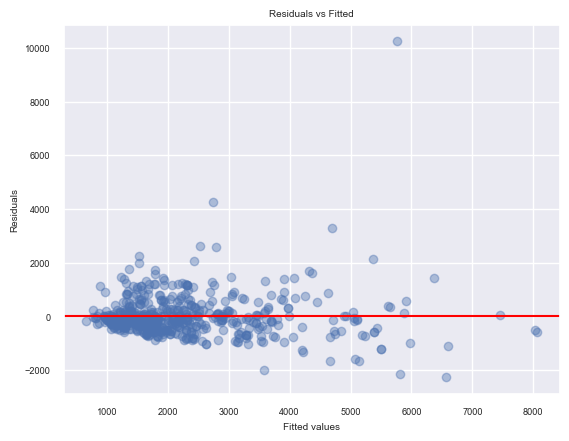

In [80]:
import matplotlib.pyplot as plt

fitted = model.fittedvalues
residuals = model.resid

plt.figure()
plt.scatter(fitted, residuals, alpha=0.4)
plt.axhline(0, color="red")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

## 2.2 Histogram of Residuals

### The histogram of residuals helps evaluate whether the error term is approximately normally distributed. Significant skewness or heavy tails may indicate that the linear specification is not fully appropriate.

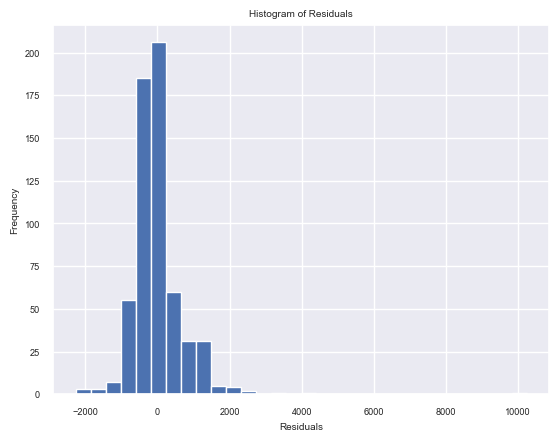

In [81]:
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

# 3. Log Model

### Given the observed right-skewness in rental prices and potential heteroskedasticity, we estimate an alternative log-linear specification. Transforming the dependent variable into logarithms helps stabilize variance and allows coefficients to be interpreted in percentage terms.

## 3.1 Linear Regression of Log Model

In [82]:
import numpy as np
import statsmodels.api as sm

# 2. Create log of Rent
train["log_Rent"] = np.log(train["Rent"])

# 3. Define dependent variable
y_log = train["log_Rent"]

# 4. Define explanatory variables (removed Cottage, Semidetached, Studio)
X_log = train[[
    "Sq.Mt",
    "Bedrooms",
    "Floor",
    "Elevator",
    "Penthouse",
    "Duplex",
    "District_Centro",
    "District_Salamanca" 
]]

# 5. Add constant
X_log = sm.add_constant(X_log)

# 6. Run log regression
model_log = sm.OLS(y_log, X_log).fit()

# 7. Print results
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:               log_Rent   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.690
Method:                 Least Squares   F-statistic:                     166.1
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          3.17e-145
Time:                        15:43:12   Log-Likelihood:                -122.34
No. Observations:                 595   AIC:                             262.7
Df Residuals:                     586   BIC:                             302.2
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  6.6340      0

## 3.2 Residual Diagnostics (Log Model)

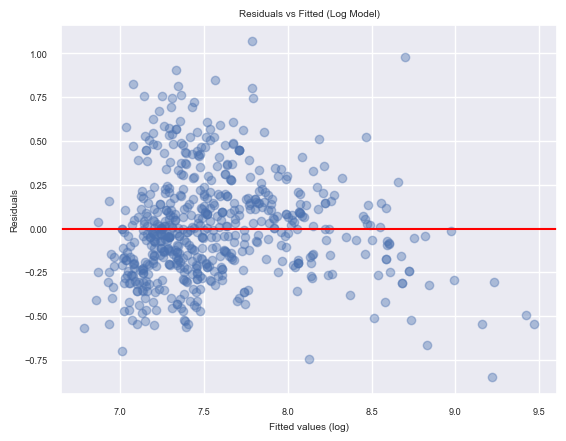

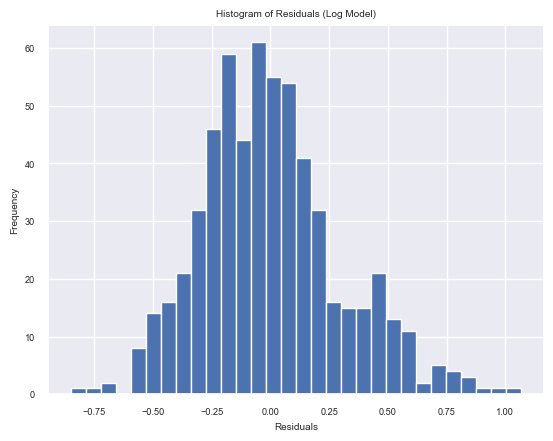

In [83]:
fitted_log = model_log.fittedvalues
residuals_log = model_log.resid

plt.figure()
plt.scatter(fitted_log, residuals_log, alpha=0.4)
plt.axhline(0, color="red")
plt.xlabel("Fitted values (log)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Log Model)")
plt.show()

plt.figure()
plt.hist(residuals_log, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals (Log Model)")
plt.show()

## 3.3 Relationship between Log(Rent) and Sq.Ml

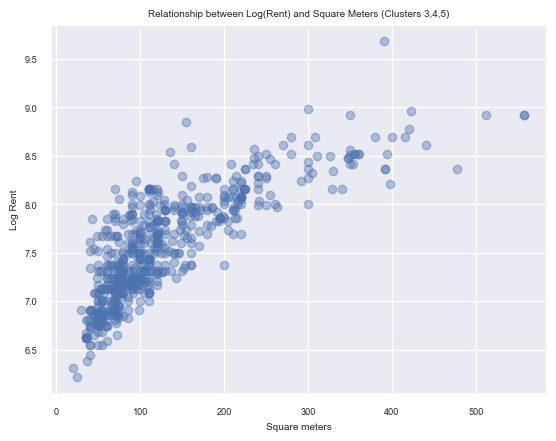

In [84]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(train["Sq.Mt"],
            train["log_Rent"],
            alpha=0.4)

plt.xlabel("Square meters")
plt.ylabel("Log Rent")
plt.title("Relationship between Log(Rent) and Square Meters (Clusters 3,4,5)")

plt.show()

### The scatterplot suggests that the relationship between square meters and rental price is not strictly linear in levels. To better capture this pattern and account for diminishing returns to size, we transformed the Square Meter variable using a logarithmic specification. The log transformation produces a more linear relationship between the variables and improves the functional form of the model.

In [85]:
import numpy as np
import statsmodels.api as sm

train["log_Rent"] = np.log(train["Rent"])
train["log_SqMt"] = np.log(train["Sq.Mt"])

y = train["log_Rent"]

X = train[[
    "log_SqMt",
    "Bedrooms",
    "Floor",
    "Elevator",
    "Penthouse",
    "Duplex",
    "District_Centro",
    "District_Salamanca"
]]

X = sm.add_constant(X)

model_loglog = sm.OLS(y, X).fit()

print(model_loglog.summary())

                            OLS Regression Results                            
Dep. Variable:               log_Rent   R-squared:                       0.737
Model:                            OLS   Adj. R-squared:                  0.733
Method:                 Least Squares   F-statistic:                     204.9
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          2.67e-164
Time:                        15:43:12   Log-Likelihood:                -77.567
No. Observations:                 595   AIC:                             173.1
Df Residuals:                     586   BIC:                             212.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  3.8812      0

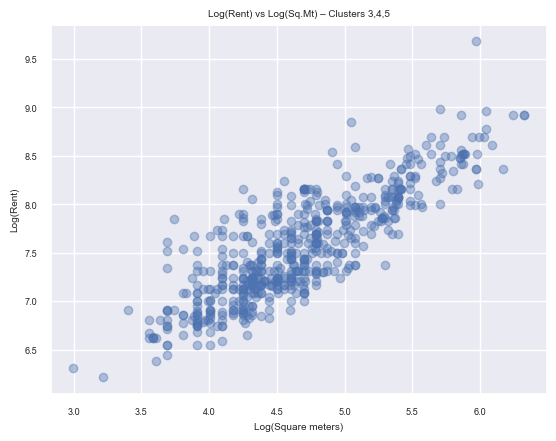

In [86]:
plt.figure()

plt.scatter(train["log_SqMt"],
            train["log_Rent"],
            alpha=0.4)

plt.xlabel("Log(Square meters)")
plt.ylabel("Log(Rent)")
plt.title("Log(Rent) vs Log(Sq.Mt) – Clusters 3,4,5")

plt.show()

# 4. VIF (multicolinearity)

### We assess whether multicollinearity may distort the interpretation of the coefficients. High multicollinearity would make it difficult to explain the independent contribution of each variable. We therefore compute the Variance Inflation Factor (VIF) for all explanatory variables in the log specification.

## 4.1 VIF

In [87]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = train[[
    "log_SqMt",
    "Bedrooms",
    "Floor",
    "Elevator",
    "Penthouse",
    "Duplex",
    "District_Centro",
    "District_Salamanca"
]].copy()

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data)

             Variable        VIF
0            log_SqMt  30.274704
1            Bedrooms   8.542048
2               Floor   4.015819
3            Elevator  13.795368
4           Penthouse   1.289911
5              Duplex   1.047461
6     District_Centro   1.639522
7  District_Salamanca   1.759532


### Testing without Elevator

In [88]:
X_vif = train[[
    "log_SqMt",
    "Bedrooms",
    "Floor",
    "Penthouse",
    "Duplex",
    "District_Centro",
    "District_Salamanca"
]].copy()

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data)

             Variable        VIF
0            log_SqMt  14.067609
1            Bedrooms   8.039407
2               Floor   3.931081
3           Penthouse   1.287421
4              Duplex   1.041450
5     District_Centro   1.616048
6  District_Salamanca   1.752872


### Test without Bedrooms but with Elevator

In [89]:
X_vif = train[[
    "log_SqMt",
    "Floor",
    "Elevator",
    "Penthouse",
    "Duplex",
    "District_Centro",
    "District_Salamanca"
]].copy()

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data)

             Variable        VIF
0            log_SqMt  14.827283
1               Floor   3.973716
2            Elevator  12.983606
3           Penthouse   1.284436
4              Duplex   1.027641
5     District_Centro   1.508172
6  District_Salamanca   1.757155


## 4.2 Checking multicolinearity

In [90]:
corr_matrix = train[[
    "log_SqMt",
    "Bedrooms",
    "Elevator"
]].corr()

print(corr_matrix)

          log_SqMt  Bedrooms  Elevator
log_SqMt  1.000000  0.799419  0.230324
Bedrooms  0.799419  1.000000  0.108372
Elevator  0.230324  0.108372  1.000000


### Since there is a high correlation between log_SqMt and Bedrooms, we remove Bedrooms from the model. 
### The VIF of Elevator remains extremely high, indicating that this variable is partially explained by other structural characteristics such as apartment size and floor level. 

# 5. Adressing Multicolinearity

## 5.1 Recursive Feature Elimination (RFECV)

### To further verify that no redundant variables remain, we apply Recursive Feature Elimination with Cross-Validation (RFECV) to select the most informative subset of predictors.

In [91]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
import pandas as pd

candidate_features = ["log_SqMt", "Penthouse", "Floor", "District_Centro", "District_Salamanca"]

X = train[candidate_features].values
y = train["log_Rent"].values

cv = KFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(estimator=LinearRegression(), cv=cv, scoring="r2")
rfecv.fit(X, y)

ranking = pd.DataFrame({
    "Feature": candidate_features,
    "Rank": rfecv.ranking_
}).sort_values("Rank")

print(ranking)
print("Optimal number of features:", rfecv.n_features_)

              Feature  Rank
0            log_SqMt     1
1           Penthouse     1
2               Floor     1
3     District_Centro     1
4  District_Salamanca     1
Optimal number of features: 5


## 5.2 Removing Bedrooms and Elevator and Re-estimating

In [92]:
X_without = train[["log_SqMt", "Floor", "Penthouse", "Duplex","District_Centro", "District_Salamanca"]]
X_without = sm.add_constant(X_without)
model_without = sm.OLS(y, X_without).fit()
print(model_without.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.737
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     274.2
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          9.75e-167
Time:                        15:43:12   Log-Likelihood:                -77.569
No. Observations:                 595   AIC:                             169.1
Df Residuals:                     588   BIC:                             199.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  3.8869      0

## 5.3 Recomputing the VIF

In [93]:
X_vif_no_bed = train[[
    "log_SqMt",
    "Floor",
    "Penthouse",
    "Duplex",
    "District_Centro",
    "District_Salamanca"
]].copy()

vif_no_bed = pd.DataFrame()
vif_no_bed["Variable"] = X_vif_no_bed.columns
vif_no_bed["VIF"] = [
    variance_inflation_factor(X_vif_no_bed.values, i)
    for i in range(X_vif_no_bed.shape[1])
]

print(vif_no_bed)

             Variable       VIF
0            log_SqMt  4.797440
1               Floor  3.850256
2           Penthouse  1.283352
3              Duplex  1.025642
4     District_Centro  1.503642
5  District_Salamanca  1.751981


## 5.4 Removing Non-Significant Variables

In [94]:
y = train["log_Rent"]

X_final = train[[
    "log_SqMt",
    "Floor",
    "District_Centro",
    "District_Salamanca"
]]

X_final = sm.add_constant(X_final)

model_final = sm.OLS(y, X_final).fit()

print(model_final.summary())

                            OLS Regression Results                            
Dep. Variable:               log_Rent   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     410.5
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          7.62e-169
Time:                        15:43:12   Log-Likelihood:                -78.752
No. Observations:                 595   AIC:                             167.5
Df Residuals:                     590   BIC:                             189.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  3.8679      0

## 5.5 Coefficient Stability

In [95]:
features_stability = ["log_SqMt", "Floor", "District_Centro", "District_Salamanca"]

B = 300
n = len(train)

coefs = []

for _ in range(B):
    sample_idx = np.random.choice(train.index, size=n, replace=True)
    df_b = train.loc[sample_idx]

    Xb = sm.add_constant(df_b[features_stability])
    yb = df_b["log_Rent"]

    model_b = sm.OLS(yb, Xb).fit()
    coefs.append(model_b.params)

coefs_df = pd.DataFrame(coefs)

print(coefs_df.describe())

            const    log_SqMt       Floor  District_Centro  District_Salamanca
count  300.000000  300.000000  300.000000       300.000000          300.000000
mean     3.864410    0.760825    0.014647         0.119009            0.177043
std      0.096303    0.021014    0.005779         0.028958            0.026924
min      3.622859    0.712576   -0.001836         0.039195            0.095166
25%      3.799923    0.745801    0.009971         0.099606            0.158914
50%      3.864367    0.759163    0.014581         0.121060            0.176610
75%      3.935658    0.775697    0.018961         0.139491            0.195225
max      4.172808    0.813775    0.032642         0.195273            0.256294


# 6. Cross Validation

### To evaluate the model’s generalization ability, we perform 5-fold cross-validation. This allows us to assess how well the final specification performs on unseen data and to detect potential overfitting.

In [96]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

features_cv = ["log_SqMt", "Floor", "District_Centro", "District_Salamanca"]

X_cv = train[features_cv].values
y_cv = train["log_Rent"].values

cv = KFold(n_splits=5, shuffle=True, random_state=42)

model_cv = LinearRegression()

scores = cross_val_score(model_cv, X_cv, y_cv, cv=cv, scoring="r2")

print("Cross-validated R² scores:", scores)
print("Mean CV R²:", scores.mean())
print("Standard deviation:", scores.std())

Cross-validated R² scores: [0.69363093 0.7408874  0.7570852  0.70196496 0.73155573]
Mean CV R²: 0.7250248430441186
Standard deviation: 0.02383055127674997


# 7. Baseline vs Final Comparison

### Finally, we compare the initial log specification with the final simplified model. Although the baseline model achieved a slightly higher in-sample R², the optimized model demonstrates similar cross-validated performance and improved robustness, reducing the risk of overfitting.

In [97]:
comparison = pd.DataFrame({
    "Model": ["Baseline (log_SqMt, Floor, Elevator, Penthouse, Duplex, District_Centro, District_Salamanca, District_Chamartín)",
              "Final (log_SqMt, Floor, District_Centro, District_Salamanca)"],
    "R_squared": [model_loglog.rsquared, model_final.rsquared],
    "Adj_R_squared": [model_loglog.rsquared_adj, model_final.rsquared_adj],
    "AIC": [model_loglog.aic, model_final.aic],
    "BIC": [model_loglog.bic, model_final.bic]
})

print(comparison)

                                               Model  R_squared  \
0  Baseline (log_SqMt, Floor, Elevator, Penthouse...   0.736700   
1  Final (log_SqMt, Floor, District_Centro, Distr...   0.735648   

   Adj_R_squared         AIC         BIC  
0       0.733106  173.133180  212.630233  
1       0.733856  167.504792  189.447599  


In [ ]:
y = train['log_Rent']
features =['log_SqMt','Floor','District_Centro','District_Salamanca'] 

X = train[features]
X_with_const = sm.add_constant(X[features])


model = sm.OLS(y, X_with_const).fit()

y_pred = model.predict(X_with_const)
y_pred

1731    7.595342
1549    7.774572
1596    7.164628
1448    7.376653
1277    7.261918
          ...   
1736    6.822389
674     6.953260
1255    7.440298
1619    6.958227
776     7.574953
Length: 595, dtype: float64

In [105]:
X_test = test[features]
X_test_with_const = sm.add_constant(X_test[features])
y_test_pred = model.predict(X_test_with_const)
y_test_pred

710     7.963638
1693    7.289145
1287    6.926047
1185    7.980483
1278    7.217861
          ...   
1196    7.686337
1686    6.645500
1777    8.375769
1551    7.507228
872     7.045059
Length: 255, dtype: float64